# We need to 

Imports

In [60]:
import numpy as np
import sys

sys.path.append('..')  # add project root

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import Datasets.load_mat_as_flat as lmf

from prog import mlps, featlib, trainer, hlprs
import Datasets.matconv as mc

import importlib
importlib.reload(mlps)
importlib.reload(trainer)

<module 'prog.trainer' from 'c:\\Users\\Ethan\\Desktop\\Research\\pde_stuff\\ethan_work\\..\\prog\\trainer.py'>

Hyperparameter initialization, Building dataset

In [61]:
# recall that from our sweeping tests, we got lambda_tv_star to be around 10e-6.
# we will attempt to learn lam_tv and lam_pde
# initialize lambda_tv, lambda_pde as 1 (the paper doesn't give clear guidance on initialization)

# learning these
lam_tv = 1e-9
lam_pde = 1.0

lr_tv = 1e-3
lr_pde = 1e-3

#not learning these
lam_reg = 0.0
lam_data = 10.0

# hyperparameters for data generation
path = "../Datasets/data/raw/burgers.mat"
noise=0.5
nu=0.02
stride_t=1
stride_x=1
part_num=1
which_part=1
seed=1432

selected_derivs = ('u','u_x','u_xx')

correct_coeffs = [0.0, 0.0, nu, -1.0]  # corresponds to the correct PDE: u_t + u*u_x - nu*u_xx = 0


lr = 1e-3
batch_size = 1000
steps = 8000
log_every = 500

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# building noisy dataset
partitions = lmf.load_burgers_mat_as_flat(mat_path=path,
                                          noise_level=noise, 
                                          stride_t=stride_t, 
                                          stride_x=stride_x, 
                                          seed=seed, 
                                          quantile_splits=part_num, 
                                          return_partitions=True)

key = [k for k in partitions if k.startswith(f'Q{which_part}:')][0]
t_np, x_np, y_np, y_noisy_np, N = partitions[key]

# torch tensors

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_clean_torch = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

print('N points:', t_np.shape[0])
print("other points:", type(x_np.shape[0]))
print('x_unique:', len(np.unique(x_np)), 't_unique:', len(np.unique(t_np)))


Using device: cuda
N points: 25856
other points: <class 'int'>
x_unique: 256 t_unique: 101


c:\Users\Ethan\Desktop\Research\pde_stuff\ethan_work\..\Datasets\load_mat_as_flat.py:30: ComplexWarning: Casting complex values to real discards the imaginary part
  u = np.asarray(u, dtype=np.float64)


Building the model

In [62]:
def tv1d_space(u_fn, t, x, eps=1e-6):
    # Returns E[ sqrt( (du/dx)^2 + eps^2 ) ]
    u = u_fn(t, x)
    ones = torch.ones_like(u)
    ux = torch.autograd.grad(
        u, x,
        grad_outputs=ones,
        create_graph=True,
        retain_graph=True,
    )[0]
    tv = torch.sqrt(ux**2 + eps**2)
    return tv.mean()

def make_models():
    u_model = mlps.SirenMLP(hidden_layers=4, hidden_size=64, first_omega_0=1.0, hidden_omega_0=1.0)
    symnet = mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False)
    return u_model, symnet

def make_trainer(u_model, symnet):
    train_config = trainer.TrainerConfig(
        lr=lr,
        lr_tv=lr_tv,
        lr_pde=lr_pde,
        lambda_pde= lam_pde,
        lambda_reg=lam_reg,
        lambda_tv= lam_tv,
        lambda_data=lam_data,
        selected_derivs=selected_derivs,
        device=device,
    )

    ft = featlib.FeatureTensor(selected_derivs, normalize=False)
    feature_builder = ft.build

    return trainer.SAPINNScalarTrainer(
        u_model=u_model,
        v_model=symnet,
        cfg=train_config,
        feature_builder=feature_builder,
    )

In [63]:
u_model, symnet = make_models()
train = make_trainer(u_model, symnet)

train.cfg.lr_tv, train.cfg.lr_pde, train.cfg.lambda_tv, train.cfg.lambda_pde

(0.001, 0.001, 1e-09, 1.0)

Training lambdas

In [64]:
print('Starting training loop...')
print(f'Initial lambda_tv: {train.lambda_tv.item()}, Initial lambda_pde: {train.lambda_pde.item():.4f}')
print(f'step {0}:')

lambda_tv_values = []
lambda_pde_values = []

train.lambda_pde.requires_grad_(True)
train.lambda_tv.requires_grad_(True)
# first, train to find best lambda values (using ADAM)
for i in range(6000): 
    t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,
                                        t_torch=t_torch,
                                        x_torch=x_torch,
                                        y_clean=y_clean_torch,
                                        y_noisy=y_noisy_torch)
    out = train.step_adam(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean, tv_fn=tv1d_space)
    lambda_tv_values.append(train.lambda_tv.item())
    lambda_pde_values.append(train.lambda_pde.item())

    if (i + 1)%log_every==0:
        print(f'step {i +1}:')
        print(f'loss {out["loss"]:.4f}')
        print(f'loss_tv_raw {out["loss_tv_raw"]:.4f}  | loss_pde_raw {out["loss_pde_raw"]:.4f}')
        print(f'loss_tv_masked" {out["mask_tv"]:}  | loss_pde_masked {out["mask_pde"]:.4f}')
        print(f'lambda_tv {train.lambda_tv.item()} | lambda_pde {train.lambda_pde.item():.4f}')
        model_loss = out["loss"]

Starting training loop...
Initial lambda_tv: 9.999999717180685e-10, Initial lambda_pde: 1.0000
step 0:
step 500:
loss 2.3114
loss_tv_raw 0.1102  | loss_pde_raw 0.0029
loss_tv_masked" 3.6907676985720173e-06  | loss_pde_masked 1.3787
lambda_tv 0.46482789516448975 | lambda_pde 1.1744
step 1000:
loss 2.6007
loss_tv_raw 0.1158  | loss_pde_raw 0.0021
loss_tv_masked" 4.937983703712234e-06  | loss_pde_masked 1.7049
lambda_tv 0.9762462973594666 | lambda_pde 1.3060
step 1500:
loss 2.5354
loss_tv_raw 0.1018  | loss_pde_raw 0.0019
loss_tv_masked" 6.140725872683106e-06  | loss_pde_masked 2.2136
lambda_tv 1.4653760194778442 | lambda_pde 1.4882
step 2000:
loss 2.4695
loss_tv_raw 0.0949  | loss_pde_raw 0.0015
loss_tv_masked" 7.1265767473960295e-06  | loss_pde_masked 2.9791
lambda_tv 1.9091620445251465 | lambda_pde 1.7265
step 2500:
loss 2.5582
loss_tv_raw 0.0915  | loss_pde_raw 0.0014
loss_tv_masked" 7.860807272663806e-06  | loss_pde_masked 4.0098
lambda_tv 2.302187204360962 | lambda_pde 2.0030
step 3

In [80]:
# now fix lambda values and train just the loss parameters (using LBFGS)
train.cfg.lr_tv = 0.0
train.cfg.lr_pde = 0.0

train.lambda_pde = nn.Parameter(torch.tensor([6.8345], device=device))
train.lambda_pde.requires_grad_(False)
train.lambda_tv.requires_grad_(False)
# 6.8345
print('Starting second training loop with fixed lambda values...')
for i in range(6000):
    # apparently, lbfgs does better with full-batch training.
    t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=1000,
                                        t_torch=t_torch,
                                        x_torch=x_torch,
                                        y_clean=y_clean_torch,
                                        y_noisy=y_noisy_torch)
    out = train.step_adam(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean, tv_fn=tv1d_space)

    if (i + 1)%500==0:
        print(f'step {i +1}:')
        print(f'loss {out["loss"]:.4f}')
        print(f'loss_tv_raw {out["loss_tv_raw"]:.4f}  | loss_pde_raw {out["loss_pde_raw"]:.4f}')
        print(f'lambda_tv {train.lambda_tv.item()} | lambda_pde {train.lambda_pde.item():.4f}')
        print(f'lambda_tv_masked {out["mask_tv"]} | lambda_pde_masked {out["mask_pde"]:.4f}')

Starting second training loop with fixed lambda values...
step 500:
loss 2.5406
loss_tv_raw 0.0903  | loss_pde_raw 0.0001
lambda_tv 5.464966297149658 | lambda_pde 6.8345
lambda_tv_masked 9.886257430480327e-06 | lambda_pde_masked 46.7104
step 1000:
loss 2.6103
loss_tv_raw 0.0796  | loss_pde_raw 0.0001
lambda_tv 5.464966297149658 | lambda_pde 6.8345
lambda_tv_masked 9.886257430480327e-06 | lambda_pde_masked 46.7104
step 1500:
loss 2.6133
loss_tv_raw 0.0875  | loss_pde_raw 0.0001
lambda_tv 5.464966297149658 | lambda_pde 6.8345
lambda_tv_masked 9.886257430480327e-06 | lambda_pde_masked 46.7104
step 2000:
loss 2.5302
loss_tv_raw 0.0890  | loss_pde_raw 0.0001
lambda_tv 5.464966297149658 | lambda_pde 6.8345
lambda_tv_masked 9.886257430480327e-06 | lambda_pde_masked 46.7104
step 2500:
loss 2.6919
loss_tv_raw 0.0850  | loss_pde_raw 0.0001
lambda_tv 5.464966297149658 | lambda_pde 6.8345
lambda_tv_masked 9.886257430480327e-06 | lambda_pde_masked 46.7104
step 3000:
loss 2.4577
loss_tv_raw 0.0940  

max_abs_diff = 0.0829385


ValueError: not enough values to unpack (expected 2, got 0)

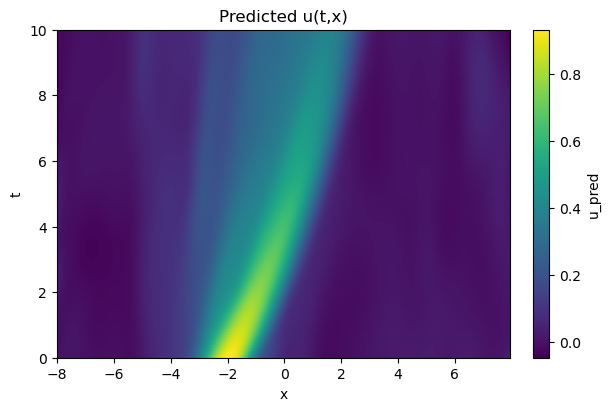

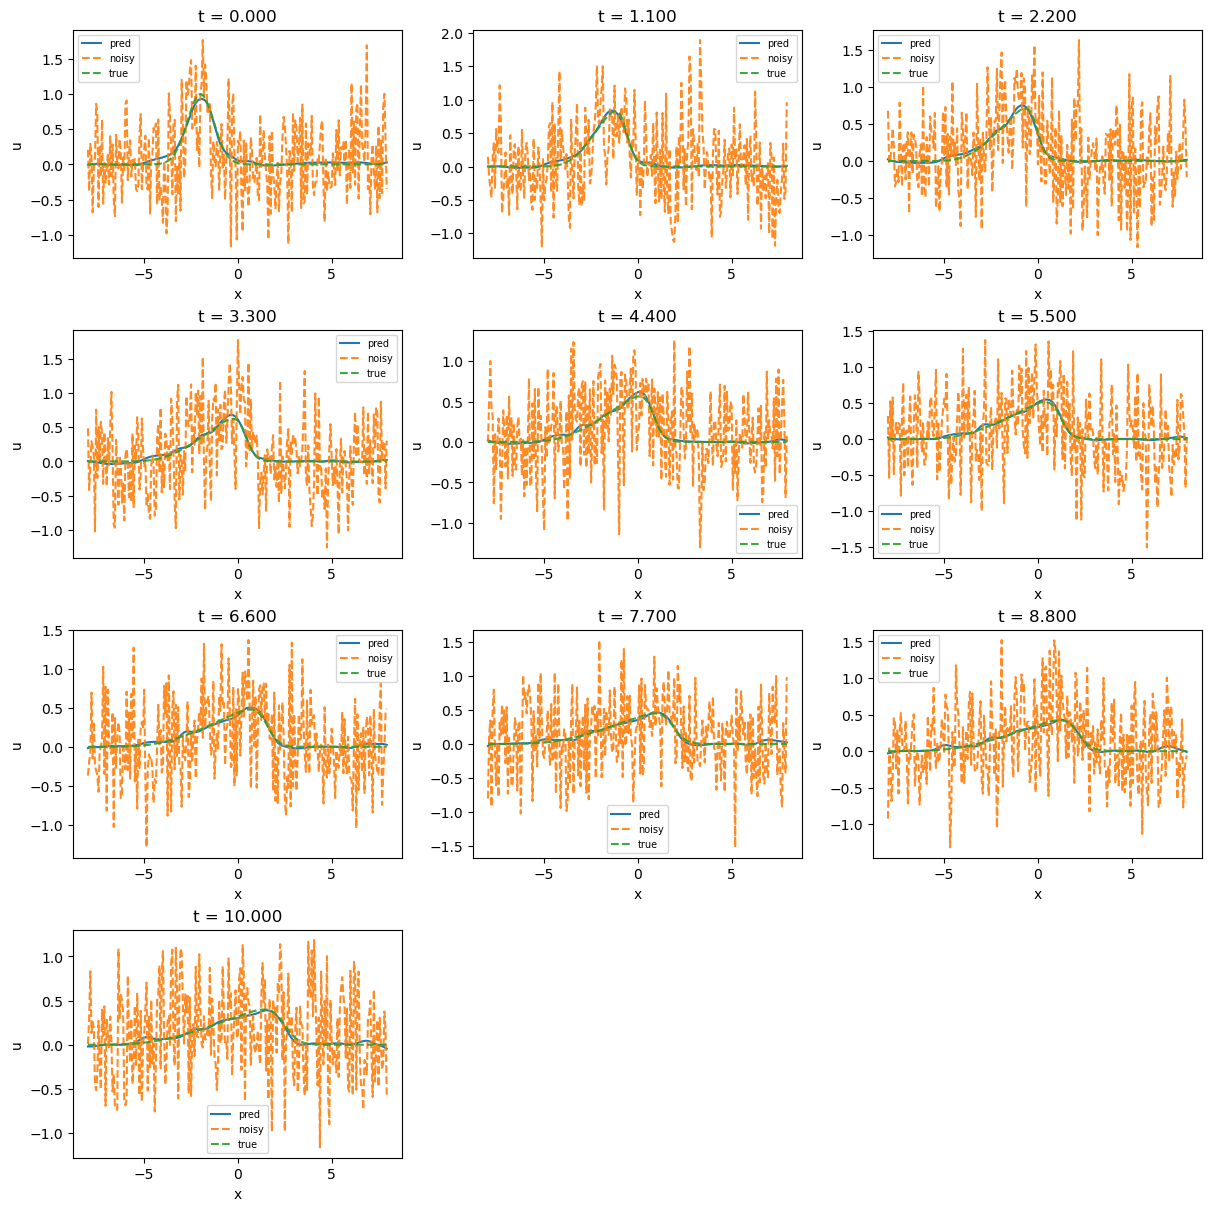

In [81]:
heatmap, plots = hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]

In [82]:
loss, aux = train.compute_loss(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean, tv_fn=tv1d_space)

In [83]:
loss

tensor([2.5534], device='cuda:0', grad_fn=<AddBackward0>)

In [84]:
aux['loss_data']

0.2549028694629669

In [97]:
lam_tv = 1e-7
lam_pde = 0.5
lam_data = 10.0

def make_models():
    u_model = mlps.SirenMLP(hidden_layers=4, hidden_size=64, first_omega_0=1.0, hidden_omega_0=1.0)
    symnet = mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False)
    return u_model, symnet

def make_trainer(u_model, symnet):
    train_config = trainer.TrainerConfig(
        lr=lr,
        lr_tv=lr_tv,
        lr_pde=lr_pde,
        lambda_pde= lam_pde,
        lambda_reg=lam_reg,
        lambda_tv= lam_tv,
        lambda_data=lam_data,
        selected_derivs=selected_derivs,
        device=device,
    )

    ft = featlib.FeatureTensor(selected_derivs, normalize=False)
    feature_builder = ft.build

    return trainer.PDETrainer(
        u_model=u_model,
        v_model=symnet,
        cfg=train_config,
        feature_builder=feature_builder,
    )

u_model_2, symnet_2 = make_models()
pde_trainer = make_trainer(u_model_2, symnet_2)
print("lambda_tv:", pde_trainer.cfg.lambda_tv)

lambda_tv: 1e-07


In [101]:
for i in range(6000):
    t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=1000,
                                        t_torch=t_torch,
                                        x_torch=x_torch,
                                        y_clean=y_clean_torch,
                                        y_noisy=y_noisy_torch)
    out = pde_trainer.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean, tv_fn=tv1d_space)

    if (i + 1)%500==0:
        print(f'step {i +1}:')
        print(f'loss {out["loss"]:.4f}')
        print(f'loss_data: {out["loss_data"]:.4f} | loss_tv: {out["loss_tv"]:.4f}  | loss_pde: {out["loss_pde"]:.4f}')

step 500:
loss 2.4584
loss_data: 0.2455 | loss_tv: 0.1130  | loss_pde: 0.0066
step 1000:
loss 2.6897
loss_data: 0.2686 | loss_tv: 0.1126  | loss_pde: 0.0065
step 1500:
loss 2.6770
loss_data: 0.2673 | loss_tv: 0.1218  | loss_pde: 0.0083
step 2000:
loss 2.5806
loss_data: 0.2577 | loss_tv: 0.1218  | loss_pde: 0.0068
step 2500:
loss 2.4664
loss_data: 0.2462 | loss_tv: 0.1330  | loss_pde: 0.0083
step 3000:
loss 2.6117
loss_data: 0.2608 | loss_tv: 0.1162  | loss_pde: 0.0081
step 3500:
loss 2.4295
loss_data: 0.2425 | loss_tv: 0.1283  | loss_pde: 0.0082
step 4000:
loss 2.3953
loss_data: 0.2391 | loss_tv: 0.1200  | loss_pde: 0.0086
step 4500:
loss 2.5257
loss_data: 0.2521 | loss_tv: 0.1235  | loss_pde: 0.0090
step 5000:
loss 2.6695
loss_data: 0.2664 | loss_tv: 0.1290  | loss_pde: 0.0100
step 5500:
loss 2.5247
loss_data: 0.2520 | loss_tv: 0.1351  | loss_pde: 0.0101
step 6000:
loss 2.3468
loss_data: 0.2341 | loss_tv: 0.1334  | loss_pde: 0.0110


max_abs_diff = 0.3259


()

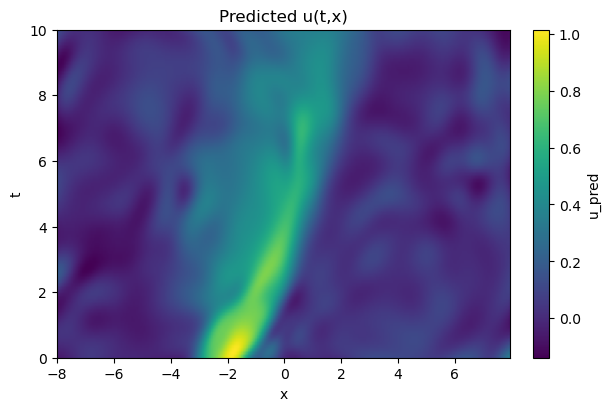

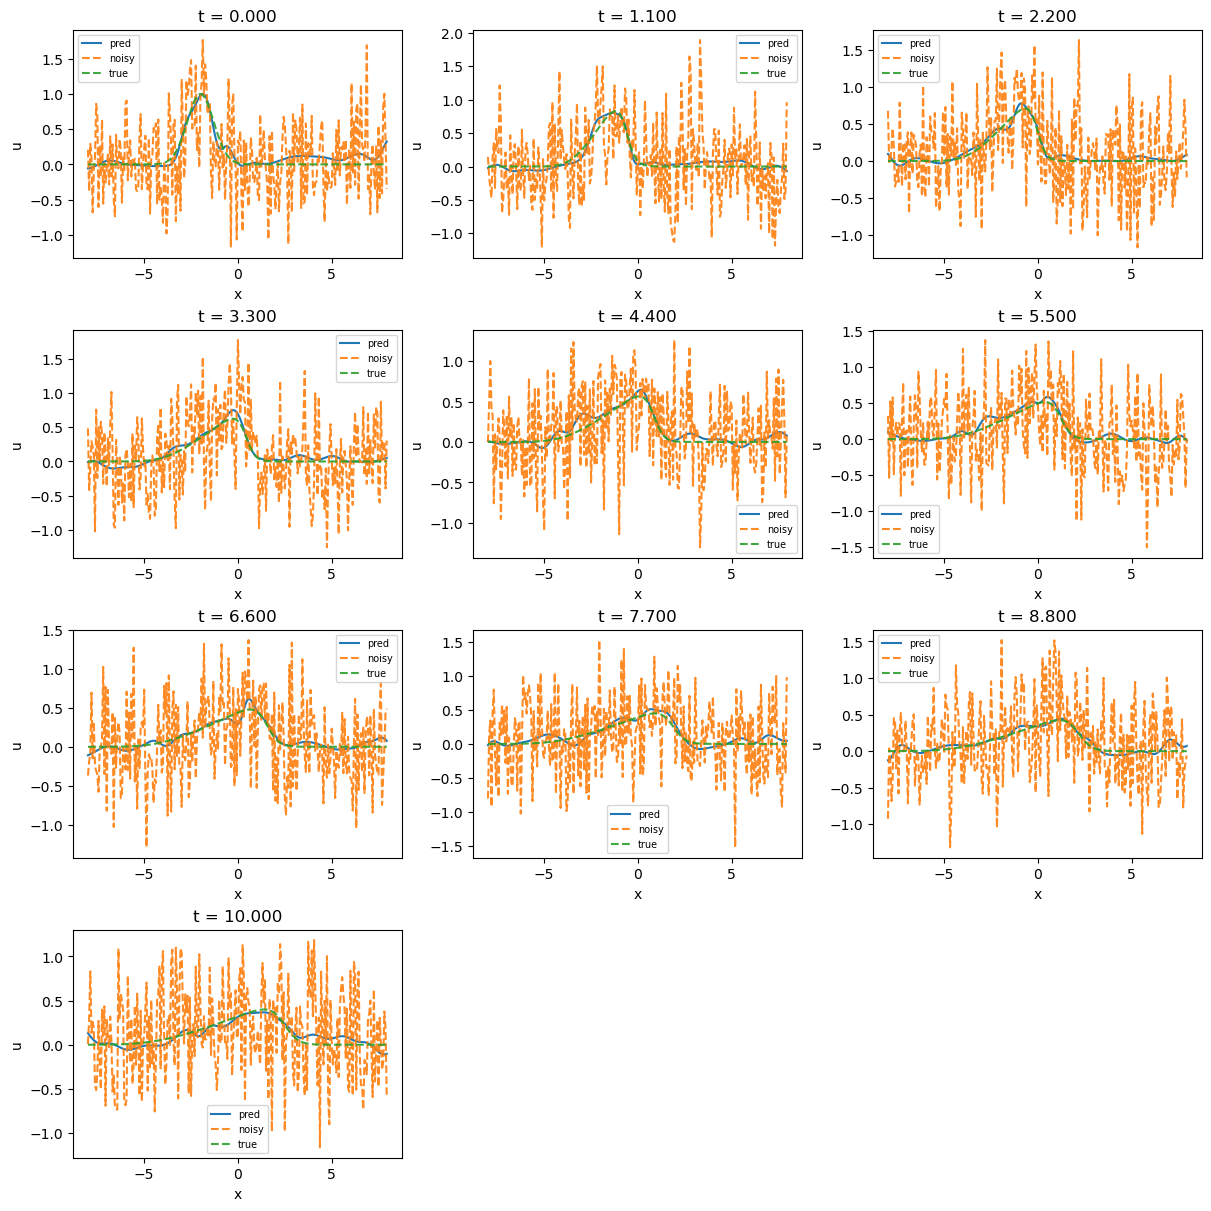

In [102]:
hlprs.snapshot_comp(pde_trainer.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0]